## Author: Lingyi Meng
## Date: 02162026

## 1. Library Setup

In [1]:
# Core
import pandas as pd
import numpy as np
import os
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

# Explainable ML
import shap

# Changepoint detection
import ruptures as rpt

c:\Users\mling\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load PennDOT Multi-Year Data

In [2]:
DATA_PATH = Path("C:/Users/mling/Desktop/Folder_A/Lingyi/Coursera/PITT/Final Project/Covid-Drivers/Covid Drivers/data/raw")

years = list(range(2005, 2025))

def load_table(table):
    dfs = []
    
    for year in years:
        file = DATA_PATH / f"Statewide_{year}" / f"{table}_{year}.csv"
        
        if file.exists():
            df = pd.read_csv(file, low_memory=False)
            df["CRASH_YEAR"] = year
            dfs.append(df)
    
    return pd.concat(dfs, ignore_index=True)

crash = load_table("CRASH")
vehicle = load_table("VEHICLE")
person = load_table("PERSON")
flags = load_table("FLAGS")
roadway = load_table("ROADWAY")

C:\Users\mling\AppData\Local\Temp\ipykernel_55908\4141231718.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["CRASH_YEAR"] = year


## 3. Aggregate Vehicle + Person Tables

In [3]:
# ---------------------------------------------------------
# Clean VEHICLE table before aggregation
# ---------------------------------------------------------

# Replace common placeholder values
vehicle = vehicle.replace(["UNKNOWN", " ", "", "NA"], np.nan)

# Convert speed to numeric safely
vehicle["TRAVEL_SPD"] = pd.to_numeric(vehicle["TRAVEL_SPD"], errors="coerce")

# Ensure vehicle type exists
if "VEH_TYPE" in vehicle.columns:
    vehicle["VEH_TYPE"] = vehicle["VEH_TYPE"].astype("category")

# Aggregate vehicle data to crash level
vehicle_agg = (
    vehicle.groupby("CRN", as_index=False)
    .agg(
        max_vehicle_speed=("TRAVEL_SPD", "max"),
        mean_vehicle_speed=("TRAVEL_SPD", "mean"),
        vehicle_type_count=("VEH_TYPE", "nunique")
    )
)


# ---------------------------------------------------------
# Clean PERSON table before aggregation
# ---------------------------------------------------------

person = person.replace(["UNKNOWN", " ", "", "NA"], np.nan)

# Convert age to numeric
person["AGE"] = pd.to_numeric(person["AGE"], errors="coerce")

# Encode gender to numeric
person["SEX"] = person["SEX"].map({"M": 1, "F": 0})

# Aggregate person data
person_agg = (
    person.groupby("CRN", as_index=False)
    .agg(
        avg_driver_age=("AGE", "mean"),
        min_driver_age=("AGE", "min"),
        max_driver_age=("AGE", "max"),
        pct_male=("SEX", "mean"),
        person_count=("SEX", "count")
    )
)

## 4. Merge All Tables

In [4]:
df = crash.merge(flags, on="CRN", how="left")

df = df.merge(vehicle_agg, on="CRN", how="left")
df = df.merge(person_agg, on="CRN", how="left")
df = df.merge(roadway, on="CRN", how="left")

## 5. Define COVID Period

In [5]:
def covid_period(year):
    
    if year <= 2019:
        return "Pre-COVID"
    elif year <= 2021:
        return "COVID"
    else:
        return "Post-COVID"

df["period"] = df["CRASH_YEAR"].apply(covid_period)

C:\Users\mling\AppData\Local\Temp\ipykernel_55908\254605665.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["period"] = df["CRASH_YEAR"].apply(covid_period)


## 6. Behavioral Risk Variables

In [6]:
behavior_flags = [
    "SPEEDING",
    "AGGRESSIVE_DRIVING",
    "ALCOHOL_RELATED",
    "DRUG_RELATED",
    "DISTRACTED",
    "RUNNING_RED_LT",
    "LANE_DEPARTURE",
    "SINGLE_VEHICLE",
    "FATIGUE_ASLEEP"
]

df[behavior_flags] = df[behavior_flags].fillna(0)

## 7. Define Outcome Variable

In [7]:
df["severe_crash"] = (df["MAX_SEVERITY_LEVEL"] >= 4).astype(int)

C:\Users\mling\AppData\Local\Temp\ipykernel_55908\1780332260.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["severe_crash"] = (df["MAX_SEVERITY_LEVEL"] >= 4).astype(int)


## 8. Feature Set

In [8]:
# Behavioral features
behavior_flags = [
    "SPEEDING",
    "AGGRESSIVE_DRIVING",
    "ALCOHOL_RELATED",
    "DRUG_RELATED",
    "DISTRACTED",
    "RUNNING_RED_LT",
    "LANE_DEPARTURE",
    "SINGLE_VEHICLE",
    "FATIGUE_ASLEEP"
]

# Numeric features
numeric_features = [
    "max_vehicle_speed",
    "vehicle_type_count",
    "avg_driver_age",
    "pct_male",
    "SPEED_LIMIT",
    "LANE_COUNT"
]

# Categorical features
categorical_features = [
    "URBAN_RURAL"
]


# temporal_features
temporal_features = [
    "CRASH_MONTH",
    "DAY_OF_WEEK",
    "HOUR_OF_DAY"
]

# Combine feature list
features = behavior_flags + numeric_features + categorical_features + temporal_features

X = df[features]
y = df["severe_crash"]

## 9. Train/Test Split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

## 10. Train Models
#### Logistic Regression (baseline)

In [10]:
# ======================================================
# Step 10: Logistic Regression Baseline Model
# ======================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Define preprocessing pipelines

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features + behavior_flags),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Create model pipeline

logit_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

# Train model

logit_model.fit(X_train, y_train)

# Predict probabilities

pred = logit_model.predict_proba(X_test)[:, 1]

# Evaluate model

print("Logistic Regression AUC:", roc_auc_score(y_test, pred))

Logistic Regression AUC: 0.6025024340974532


## Step11 Random Forest Model

In [11]:
# ======================================================
# Step 11: Random Forest Model
# ======================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", rf_model)
    ]
)

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict_proba(X_test)[:,1]

print("Random Forest AUC:", roc_auc_score(y_test, rf_pred))

Random Forest AUC: 0.6417512728597432


## Step 12 — XGBoost Model

In [12]:
# ======================================================
# Step 12: XGBoost Model
# ======================================================

import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    random_state=42,
    scale_pos_weight=10
)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", xgb_model)
    ]
)

xgb_pipeline.fit(X_train, y_train)

xgb_pred = xgb_pipeline.predict_proba(X_test)[:,1]

print("XGBoost AUC:", roc_auc_score(y_test, xgb_pred))

XGBoost AUC: 0.6481156453373222


## Step 13 — Model Comparison Plot

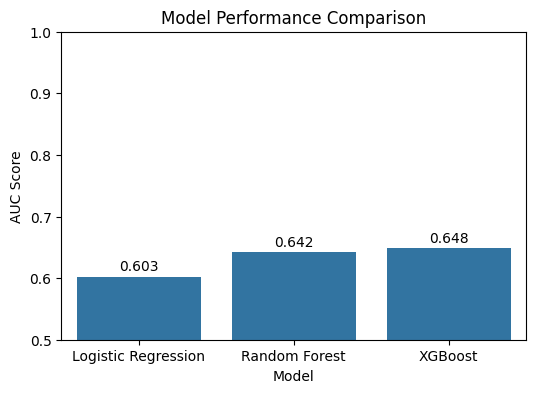

In [14]:
# ======================================================
# Step 13: Model Performance Comparison
# ======================================================


model_scores = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest","XGBoost"],
    "AUC":[
        roc_auc_score(y_test,pred),
        roc_auc_score(y_test,rf_pred),
        roc_auc_score(y_test,xgb_pred)
    ]
})

plt.figure(figsize=(6,4))

ax = sns.barplot(data=model_scores, x="Model", y="AUC")

# Add data labels
for i, v in enumerate(model_scores["AUC"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=10)

plt.title("Model Performance Comparison")
plt.ylim(0.5,1)
plt.ylabel("AUC Score")

plt.show()

## 14 Split dataset into Pre/Post COVID

In [15]:

# ======================================================
# Step 14: Prepare dataset for Pre/Post COVID comparison
# ======================================================

# Only keep columns needed for modeling to reduce memory
ml_columns = features + ["severe_crash", "CRASH_YEAR"]

df_ml = df.loc[:, ml_columns]

# Split dataset by year
pre_df = df_ml.loc[df_ml["CRASH_YEAR"] <= 2019]
post_df = df_ml.loc[df_ml["CRASH_YEAR"] >= 2022]

# Print dataset sizes
print("Pre-COVID crashes:", len(pre_df))
print("Post-COVID crashes:", len(post_df))

Pre-COVID crashes: 2943045
Post-COVID crashes: 530707


## Step 15 — Train Pre-COVID Random Forest Model

In [16]:
# ======================================================
# Step 15: Train Pre-COVID Random Forest Model
# ======================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# Optional but recommended: balance sample size
pre_df_sample = pre_df.sample(len(post_df), random_state=42)

# Separate features and target
X_pre = pre_df_sample[features]
y_pre = pre_df_sample["severe_crash"]

# Train/test split
X_train_pre, X_test_pre, y_train_pre, y_test_pre = train_test_split(
    X_pre,
    y_pre,
    test_size=0.25,
    random_state=42,
    stratify=y_pre
)

# Random Forest model
rf_pre = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_pre.fit(X_train_pre, y_train_pre)

# Predictions
pre_pred = rf_pre.predict_proba(X_test_pre)[:, 1]

# Evaluate model
print("Pre-COVID Random Forest AUC:", roc_auc_score(y_test_pre, pre_pred))

Pre-COVID Random Forest AUC: 0.6458454996928958


## Step 16 — Train Post-COVID Random Forest Model

In [17]:
# ======================================================
# Step 16: Train Post-COVID Random Forest Model
# ======================================================

# Separate features and target
X_post = post_df[features]
y_post = post_df["severe_crash"]

# Train/test split
X_train_post, X_test_post, y_train_post, y_test_post = train_test_split(
    X_post,
    y_post,
    test_size=0.25,
    random_state=42,
    stratify=y_post
)

# Random Forest model (same parameters as Pre-COVID model)
rf_post = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_post.fit(X_train_post, y_train_post)

# Predictions
post_pred = rf_post.predict_proba(X_test_post)[:,1]

# Evaluate model
print("Post-COVID Random Forest AUC:", roc_auc_score(y_test_post, post_pred))

Post-COVID Random Forest AUC: 0.6509200455572304


## Step 17 — Extract Feature Importance

In [18]:
importance_pre = pd.Series(
    rf_pre.feature_importances_,
    index=features
)

importance_post = pd.Series(
    rf_post.feature_importances_,
    index=features
)

## Step 18 — Compare Importance Change

In [19]:
# ======================================================
# Step 18: Normalize Importance Change
# ======================================================
comparison = pd.DataFrame({
    "Pre-COVID": importance_pre,
    "Post-COVID": importance_post
})


comparison["Relative_Change"] = (
    comparison["Post-COVID"] - comparison["Pre-COVID"]
) / comparison["Pre-COVID"]

comparison = comparison.sort_values("Relative_Change", ascending=False)

print(comparison)

                    Pre-COVID  Post-COVID  Relative_Change
avg_driver_age       0.138986    0.317708         1.285902
HOUR_OF_DAY          0.017692    0.027886         0.576163
SPEEDING             0.004975    0.007006         0.408293
DAY_OF_WEEK          0.026645    0.031494         0.181983
pct_male             0.146732    0.163144         0.111847
DRUG_RELATED         0.006793    0.006790        -0.000529
RUNNING_RED_LT       0.005293    0.005267        -0.004785
CRASH_MONTH          0.040033    0.039634        -0.009964
DISTRACTED           0.012928    0.012385        -0.041983
FATIGUE_ASLEEP       0.004111    0.003894        -0.052697
URBAN_RURAL          0.054311    0.050886        -0.063066
max_vehicle_speed    0.133226    0.114171        -0.143028
AGGRESSIVE_DRIVING   0.021808    0.015284        -0.299172
ALCOHOL_RELATED      0.011916    0.007685        -0.355091
SPEED_LIMIT          0.086879    0.055983        -0.355619
LANE_COUNT           0.030501    0.018326        -0.3991

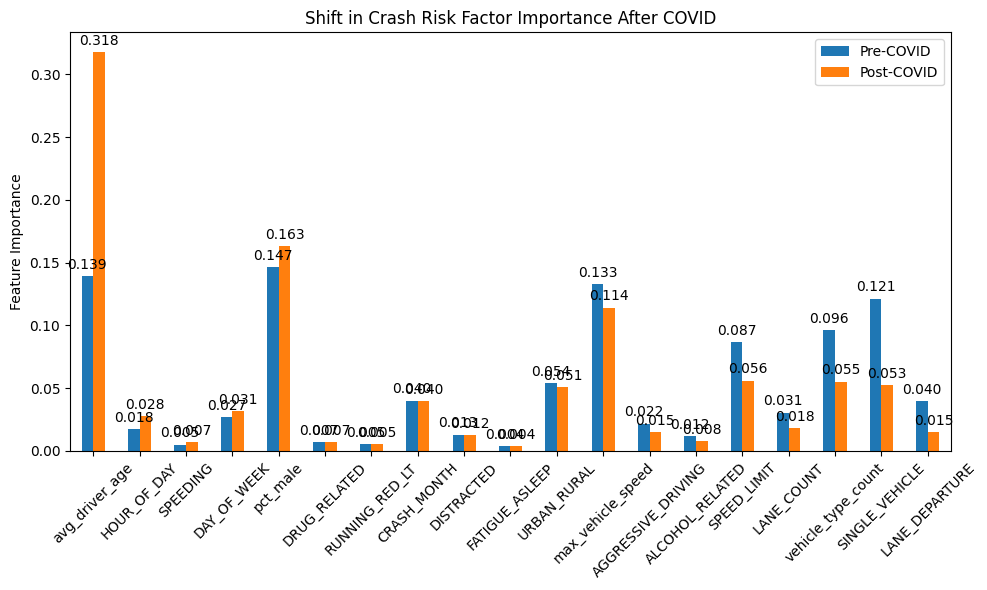

In [20]:
## Visualization 
ax = comparison[["Pre-COVID","Post-COVID"]].plot.bar(
    figsize=(10,6)
)

plt.title("Shift in Crash Risk Factor Importance After COVID")
plt.ylabel("Feature Importance")
plt.xticks(rotation=45)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

## Step 19 — XGBoost Feature Importance Robustness Check

In [21]:
# ======================================================
# Step 19: XGBoost Feature Importance Comparison
# ======================================================

import xgboost as xgb

# Pre-COVID XGBoost model
xgb_pre = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    random_state=42,
    scale_pos_weight=10
)

xgb_pre.fit(pre_df[features], pre_df["severe_crash"])


# Post-COVID XGBoost model
xgb_post = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    random_state=42,
    scale_pos_weight=10
)

xgb_post.fit(post_df[features], post_df["severe_crash"])

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## Step 19.5 — Extract XGBoost Feature Importance

In [22]:
importance_pre_xgb = pd.Series(
    xgb_pre.feature_importances_,
    index=features
)

importance_post_xgb = pd.Series(
    xgb_post.feature_importances_,
    index=features
)

## Step 19.6 — Compare Importance Change

In [23]:
comparison_xgb = pd.DataFrame({
    "Pre-COVID": importance_pre_xgb,
    "Post-COVID": importance_post_xgb
})

comparison_xgb["Change"] = (
    comparison_xgb["Post-COVID"] - comparison_xgb["Pre-COVID"]
)

comparison_xgb["Relative_Change"] = (
    comparison_xgb["Post-COVID"] - comparison_xgb["Pre-COVID"]
) / comparison_xgb["Pre-COVID"]

comparison_xgb = comparison_xgb.sort_values("Relative_Change", ascending=False)

print(comparison_xgb)

                    Pre-COVID  Post-COVID    Change  Relative_Change
DAY_OF_WEEK          0.007737    0.023900  0.016163         2.089122
HOUR_OF_DAY          0.009322    0.027582  0.018260         1.958787
SPEEDING             0.014322    0.039080  0.024757         1.728567
avg_driver_age       0.039475    0.078945  0.039470         0.999881
DRUG_RELATED         0.022604    0.044899  0.022294         0.986296
RUNNING_RED_LT       0.018749    0.036994  0.018245         0.973120
FATIGUE_ASLEEP       0.019650    0.032862  0.013212         0.672395
URBAN_RURAL          0.102715    0.167122  0.064407         0.627052
LANE_COUNT           0.017306    0.025542  0.008236         0.475901
DISTRACTED           0.026171    0.037697  0.011526         0.440419
CRASH_MONTH          0.020992    0.028716  0.007724         0.367965
ALCOHOL_RELATED      0.032227    0.036363  0.004136         0.128336
AGGRESSIVE_DRIVING   0.046594    0.040235 -0.006359        -0.136473
max_vehicle_speed    0.066280    0

## Step 19 — Visualization

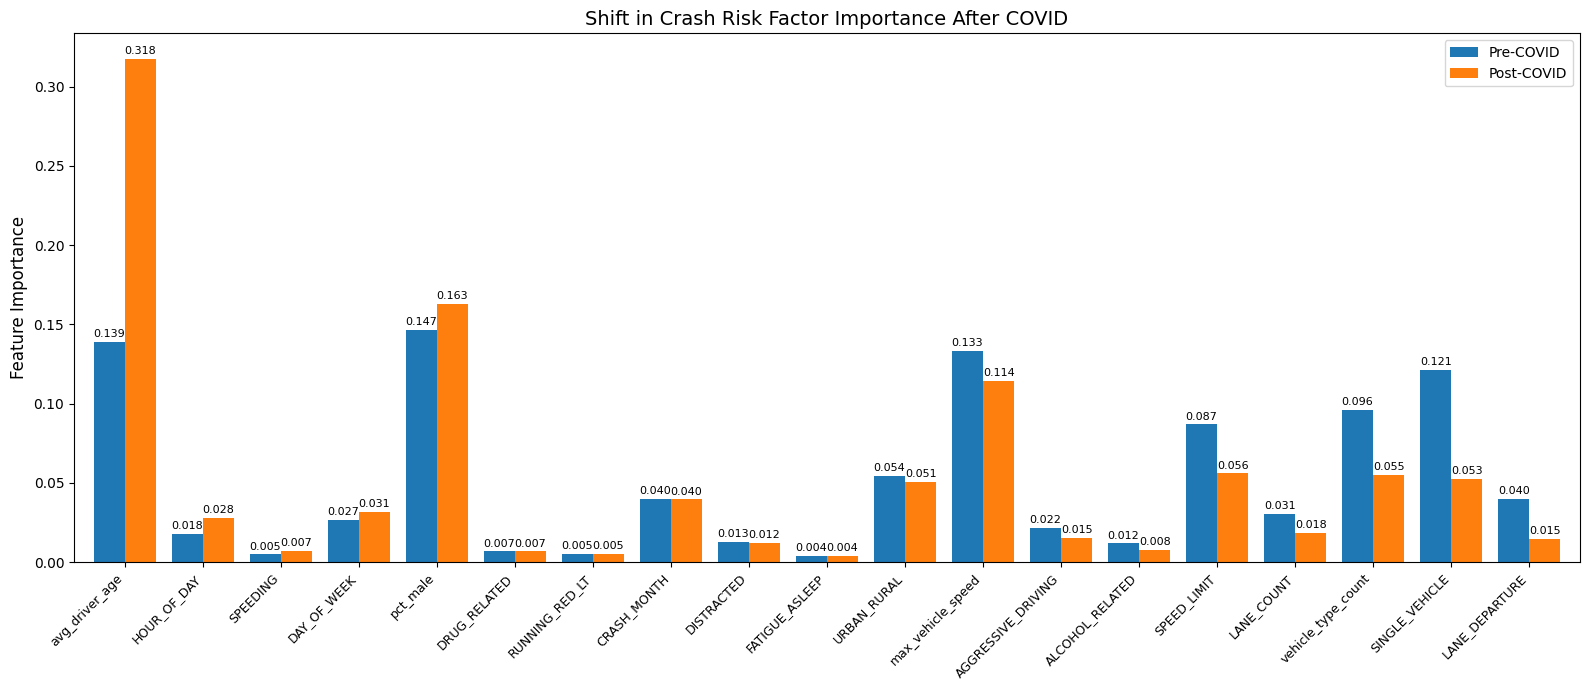

In [24]:
## Visualization with data labels
## Wider visualization with data labels
ax = comparison[["Pre-COVID","Post-COVID"]].plot.bar(
    figsize=(16,7),   # make figure wider
    width=0.8
)

plt.title("Shift in Crash Risk Factor Importance After COVID", fontsize=14)
plt.ylabel("Feature Importance", fontsize=12)

plt.xticks(rotation=45, ha="right", fontsize=9)

# Add data labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=2,
        fontsize=8
    )

plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Step 20 — Temporal Behavioral Trends

In [25]:
# ======================================================
# Step 20: Temporal Behavioral Trends
# ======================================================

trend_vars = [
    "SPEEDING",
    "AGGRESSIVE_DRIVING",
    "DISTRACTED",
    "ALCOHOL_RELATED",
    "DRUG_RELATED",
    "RUNNING_RED_LT",
    "LANE_DEPARTURE",
    "SINGLE_VEHICLE",
    "FATIGUE_ASLEEP",
    "severe_crash"
]

yearly_trends = (
    df.groupby("CRASH_YEAR")[trend_vars]
    .mean()
    .reset_index()
)

print(yearly_trends.head())

   CRASH_YEAR  SPEEDING  AGGRESSIVE_DRIVING  DISTRACTED  ALCOHOL_RELATED  \
0      2005.0  0.038545            0.619064    0.088557         0.088709   
1      2006.0  0.040665            0.611726    0.094152         0.094157   
2      2007.0  0.037840            0.613856    0.092726         0.090043   
3      2008.0  0.030563            0.596320    0.096397         0.092774   
4      2009.0  0.028875            0.602286    0.100861         0.086951   

   DRUG_RELATED  RUNNING_RED_LT  LANE_DEPARTURE  SINGLE_VEHICLE  \
0      0.015064        0.061317        0.231657        0.334399   
1      0.017855        0.067065        0.218498        0.327662   
2      0.018477        0.062549        0.240027        0.347277   
3      0.020359        0.060376        0.251893        0.362275   
4      0.021585        0.061890        0.231004        0.343440   

   FATIGUE_ASLEEP  severe_crash  
0        0.013847      0.451804  
1        0.014221      0.451092  
2        0.013870      0.438327  
3   

## Step 21 — Plot key behavioral trends

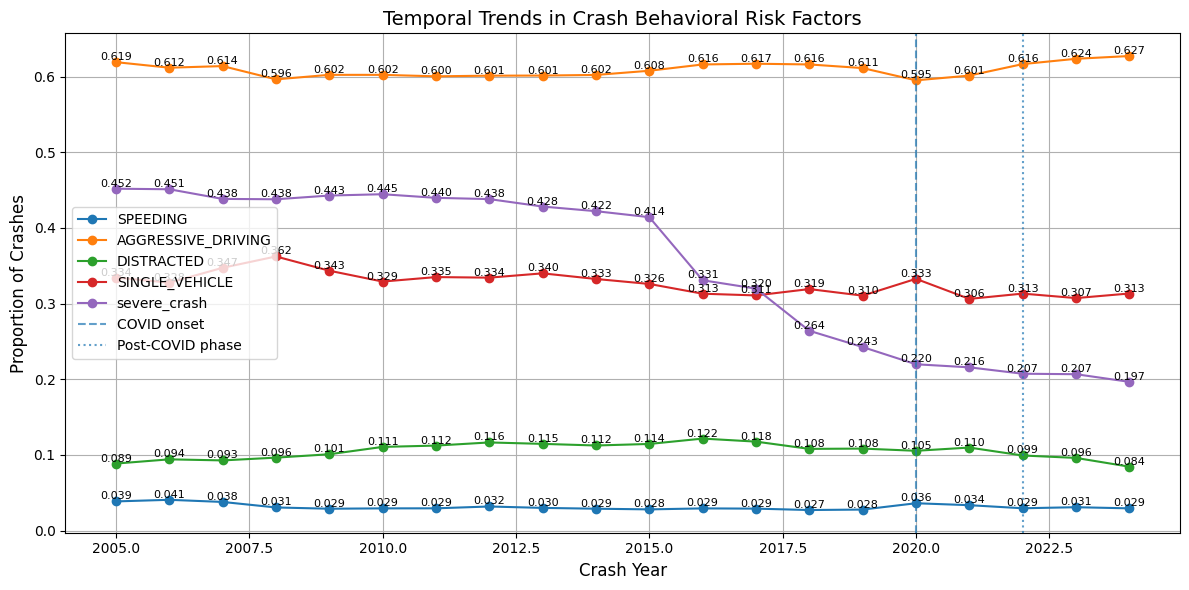

In [26]:
# ======================================================
# Step 21: Plot key behavioral trends
# ======================================================

plot_vars = [
    "SPEEDING",
    "AGGRESSIVE_DRIVING",
    "DISTRACTED",
    "SINGLE_VEHICLE",
    "severe_crash"
]

plt.figure(figsize=(12, 6))  # slightly wider for readability

for col in plot_vars:
    plt.plot(yearly_trends["CRASH_YEAR"], yearly_trends[col], marker="o", label=col)

    # Add data labels for each point
    for x, y in zip(yearly_trends["CRASH_YEAR"], yearly_trends[col]):
        plt.text(
            x, y,
            f"{y:.3f}",       # label format
            fontsize=8,
            ha="center",
            va="bottom"
        )

plt.axvline(2020, linestyle="--", alpha=0.7, label="COVID onset")
plt.axvline(2022, linestyle=":", alpha=0.7, label="Post-COVID phase")

plt.title("Temporal Trends in Crash Behavioral Risk Factors", fontsize=14)
plt.xlabel("Crash Year", fontsize=12)
plt.ylabel("Proportion of Crashes", fontsize=12)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 22 — Make a cleaner long-format plot

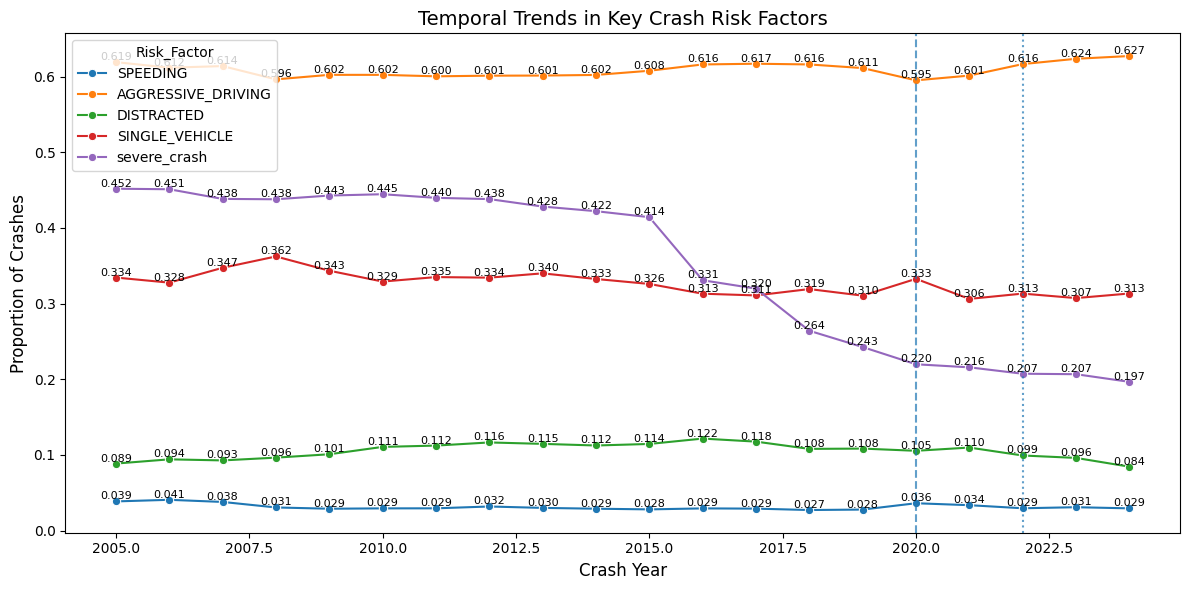

In [27]:
trend_long = yearly_trends.melt(
    id_vars="CRASH_YEAR",
    value_vars=plot_vars,
    var_name="Risk_Factor",
    value_name="Proportion"
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=trend_long,
    x="CRASH_YEAR",
    y="Proportion",
    hue="Risk_Factor",
    marker="o"
)

# Add data labels
for _, row in trend_long.iterrows():
    plt.text(
        row["CRASH_YEAR"],
        row["Proportion"],
        f"{row['Proportion']:.3f}",
        fontsize=8,
        ha="center",
        va="bottom"
    )

plt.axvline(2020, linestyle="--", alpha=0.7)
plt.axvline(2022, linestyle=":", alpha=0.7)

plt.title("Temporal Trends in Key Crash Risk Factors", fontsize=14)
plt.xlabel("Crash Year", fontsize=12)
plt.ylabel("Proportion of Crashes", fontsize=12)

plt.tight_layout()
plt.show()

## Step 23 — Period comparison summary table

In [28]:
# ======================================================
# Step 23: Period summary table
# ======================================================

period_summary = (
    df.groupby("period")[trend_vars]
    .mean()
    .T
)

print(period_summary)

period                 COVID  Post-COVID  Pre-COVID
SPEEDING            0.034757    0.029910   0.031191
AGGRESSIVE_DRIVING  0.598363    0.622295   0.608079
DISTRACTED          0.107710    0.093323   0.107265
ALCOHOL_RELATED     0.067348    0.063767   0.080855
DRUG_RELATED        0.033829    0.024308   0.023769
RUNNING_RED_LT      0.067581    0.067658   0.062048
LANE_DEPARTURE      0.206827    0.192790   0.217342
SINGLE_VEHICLE      0.318588    0.311281   0.330793
FATIGUE_ASLEEP      0.015184    0.017542   0.015438
severe_crash        0.217630    0.203565   0.396946


## Step 24 — Add percent change by period

In [29]:
# ======================================================
# Step 24: Change from Pre-COVID to Post-COVID
# ======================================================

period_summary["Absolute_Change_Post_vs_Pre"] = (
    period_summary["Post-COVID"] - period_summary["Pre-COVID"]
)

period_summary["Relative_Change_Post_vs_Pre"] = (
    period_summary["Post-COVID"] - period_summary["Pre-COVID"]
) / period_summary["Pre-COVID"]

print(period_summary.sort_values("Relative_Change_Post_vs_Pre", ascending=False))

period                 COVID  Post-COVID  Pre-COVID  \
FATIGUE_ASLEEP      0.015184    0.017542   0.015438   
RUNNING_RED_LT      0.067581    0.067658   0.062048   
AGGRESSIVE_DRIVING  0.598363    0.622295   0.608079   
DRUG_RELATED        0.033829    0.024308   0.023769   
SPEEDING            0.034757    0.029910   0.031191   
SINGLE_VEHICLE      0.318588    0.311281   0.330793   
LANE_DEPARTURE      0.206827    0.192790   0.217342   
DISTRACTED          0.107710    0.093323   0.107265   
ALCOHOL_RELATED     0.067348    0.063767   0.080855   
severe_crash        0.217630    0.203565   0.396946   

period              Absolute_Change_Post_vs_Pre  Relative_Change_Post_vs_Pre  
FATIGUE_ASLEEP                         0.002104                     0.136299  
RUNNING_RED_LT                         0.005610                     0.090412  
AGGRESSIVE_DRIVING                     0.014216                     0.023379  
DRUG_RELATED                           0.000539                     0.022698  

## Step 25: Heatmap of period-level behavioral prevalence

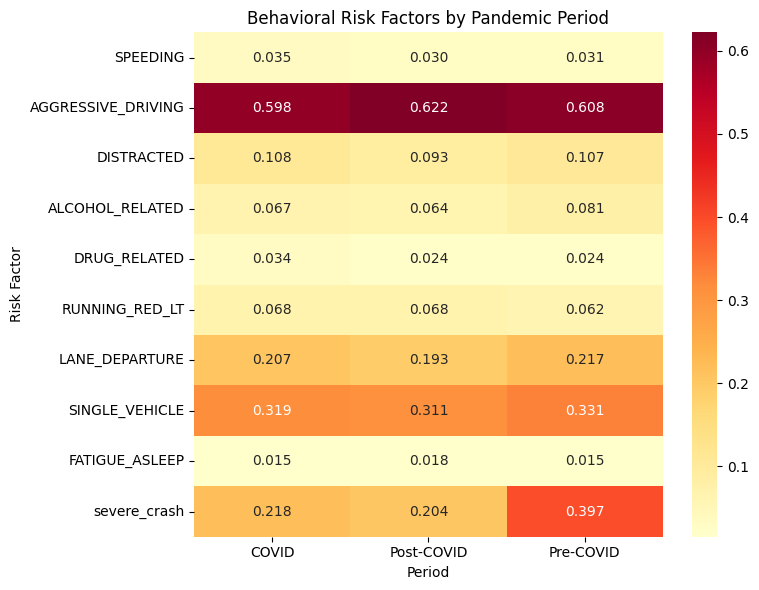

In [30]:
# ======================================================
# Step 25: Heatmap of period-level behavioral prevalence
# ======================================================

heatmap_vars = [
    "SPEEDING",
    "AGGRESSIVE_DRIVING",
    "DISTRACTED",
    "ALCOHOL_RELATED",
    "DRUG_RELATED",
    "RUNNING_RED_LT",
    "LANE_DEPARTURE",
    "SINGLE_VEHICLE",
    "FATIGUE_ASLEEP",
    "severe_crash"
]

period_heatmap = df.groupby("period")[heatmap_vars].mean().T

plt.figure(figsize=(8, 6))
sns.heatmap(period_heatmap, annot=True, fmt=".3f", cmap="YlOrRd")

plt.title("Behavioral Risk Factors by Pandemic Period")
plt.xlabel("Period")
plt.ylabel("Risk Factor")
plt.tight_layout()
plt.show()

## Step 26 — SHAP for the overall XGBoost model


In [31]:
# ======================================================
# Step 26: SHAP Explainability for Pre/Post COVID Models
# ======================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sample data to reduce computation
pre_sample = pre_df[features].sample(2000, random_state=42)
post_sample = post_df[features].sample(2000, random_state=42)

# ======================================================
# SHAP for Pre-COVID model
# ======================================================

explainer_pre = shap.TreeExplainer(xgb_pre)

shap_values_pre = explainer_pre.shap_values(pre_sample)

if isinstance(shap_values_pre, list):
    shap_values_pre = shap_values_pre[1]

# ======================================================
# SHAP for Post-COVID model
# ======================================================

explainer_post = shap.TreeExplainer(xgb_post)

shap_values_post = explainer_post.shap_values(post_sample)

if isinstance(shap_values_post, list):
    shap_values_post = shap_values_post[1]

# ======================================================
# Compute SHAP feature importance
# ======================================================

shap_importance_pre = np.abs(shap_values_pre).mean(axis=0)
shap_importance_post = np.abs(shap_values_post).mean(axis=0)

shap_comparison = pd.DataFrame({
    "Feature": features,
    "Pre-COVID": shap_importance_pre,
    "Post-COVID": shap_importance_post
})

shap_comparison["Change"] = (
    shap_comparison["Post-COVID"] - shap_comparison["Pre-COVID"]
)

shap_comparison = shap_comparison.sort_values("Change", ascending=False)

print(shap_comparison)

               Feature  Pre-COVID  Post-COVID    Change
11      avg_driver_age   0.104057    0.187454  0.083397
15         URBAN_RURAL   0.063947    0.104369  0.040422
9    max_vehicle_speed   0.141604    0.173156  0.031552
17         DAY_OF_WEEK   0.012562    0.025280  0.012718
18         HOUR_OF_DAY   0.005939    0.016362  0.010424
4           DISTRACTED   0.017019    0.024121  0.007102
1   AGGRESSIVE_DRIVING   0.040008    0.046853  0.006845
6       LANE_DEPARTURE   0.030156    0.033535  0.003380
0             SPEEDING   0.005365    0.006381  0.001016
3         DRUG_RELATED   0.005161    0.005735  0.000574
2      ALCOHOL_RELATED   0.012197    0.010926 -0.001271
8       FATIGUE_ASLEEP   0.004579    0.002724 -0.001855
5       RUNNING_RED_LT   0.011848    0.008988 -0.002859
10  vehicle_type_count   0.112904    0.096672 -0.016232
16         CRASH_MONTH   0.063767    0.043378 -0.020389
7       SINGLE_VEHICLE   0.082480    0.058998 -0.023482
13         SPEED_LIMIT   0.086783    0.062527 -0

## Step 27 — SHAP for Pre-COVID vs Post-COVID models

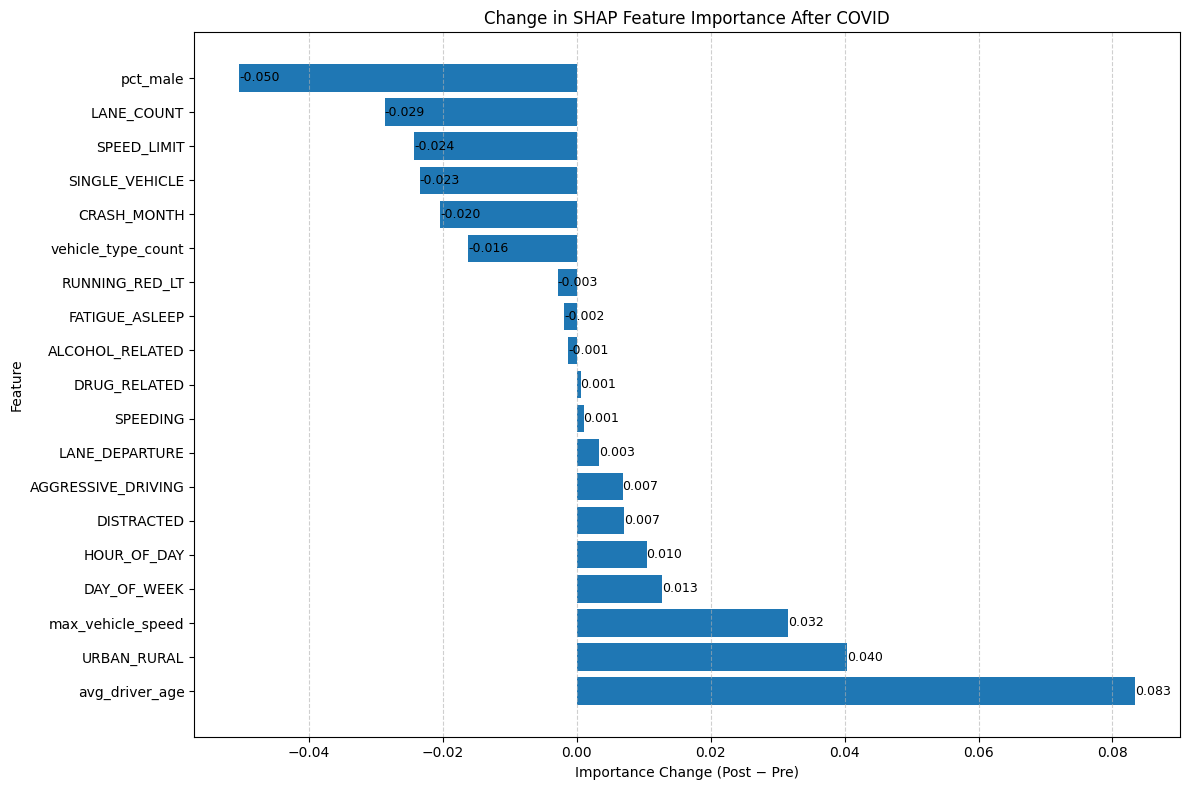

In [ ]:
# ======================================================
# Step 27: SHAP comparison for Pre- and Post-COVID
# ======================================================
# Take manageable samples
pre_sample = pre_df.sample(2000, random_state=42)
post_sample = post_df.sample(2000, random_state=42)

X_pre_sample = pre_sample[features]
X_post_sample = post_sample[features]

# SHAP explainers
explainer_pre = shap.TreeExplainer(xgb_pre)
explainer_post = shap.TreeExplainer(xgb_post)

# SHAP values
shap_values_pre = explainer_pre.shap_values(X_pre_sample)
shap_values_post = explainer_post.shap_values(X_post_sample)

# Handle binary classification output
if isinstance(shap_values_pre, list):
    shap_values_pre = shap_values_pre[1]

if isinstance(shap_values_post, list):
    shap_values_post = shap_values_post[1]

# ======================================================
# Compute SHAP importance
# ======================================================

importance_pre = np.abs(shap_values_pre).mean(axis=0)
importance_post = np.abs(shap_values_post).mean(axis=0)

shap_compare = pd.DataFrame({
    "Feature": features,
    "Pre-COVID": importance_pre,
    "Post-COVID": importance_post
})

shap_compare["Change"] = shap_compare["Post-COVID"] - shap_compare["Pre-COVID"]

# Sort by change
shap_compare = shap_compare.sort_values("Change", ascending=False)

# ======================================================
# Visualization with data labels
# ======================================================

plt.figure(figsize=(12,8))

bars = plt.barh(
    shap_compare["Feature"],
    shap_compare["Change"]
)

# Add data labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        fontsize=9
    )

plt.title("Change in SHAP Feature Importance After COVID")
plt.xlabel("Importance Change (Post − Pre)")
plt.ylabel("Feature")

plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

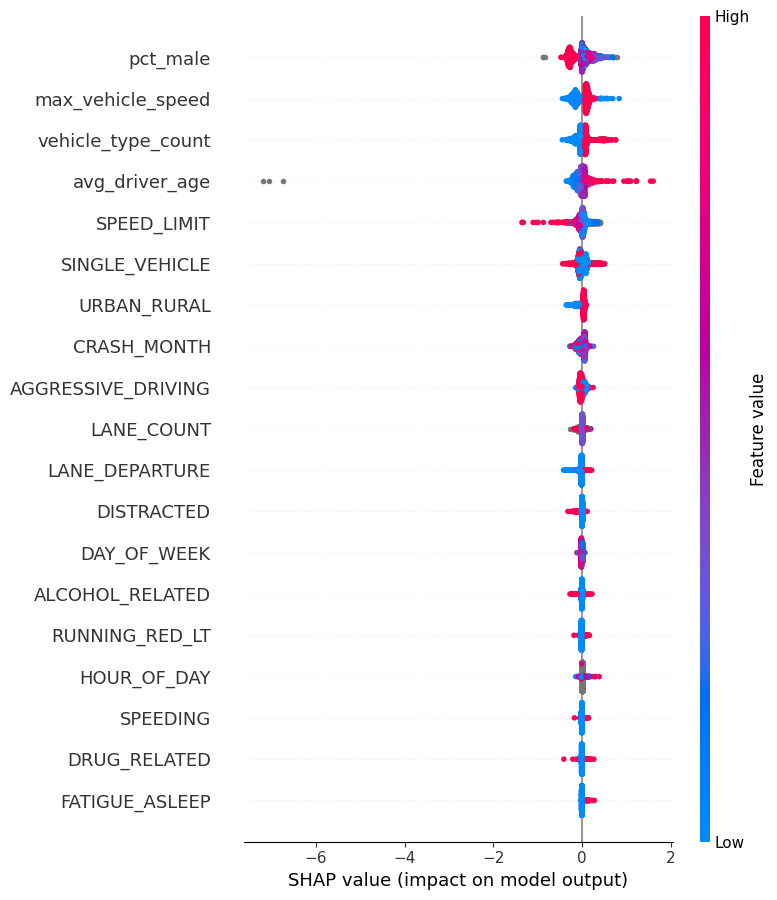

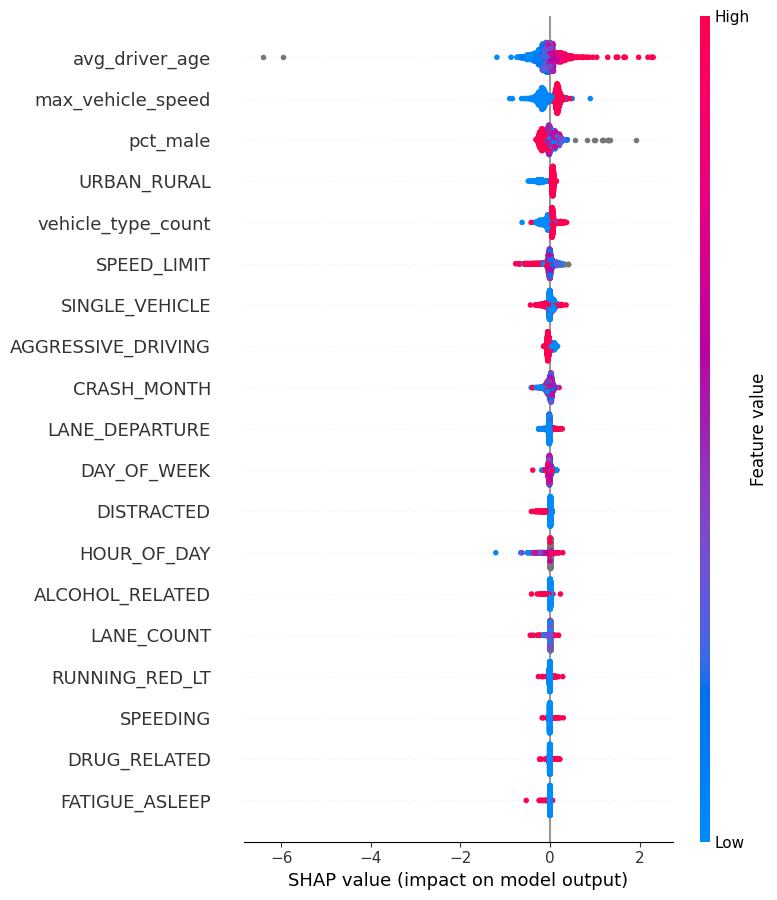

In [32]:
# ======================================================
# Step 27: SHAP comparison for Pre- and Post-COVID
# ======================================================

# Take manageable samples
pre_sample = pre_df.sample(2000, random_state=42)
post_sample = post_df.sample(2000, random_state=42)

X_pre_sample = pre_sample[features]
X_post_sample = post_sample[features]

# SHAP explainers
explainer_pre = shap.TreeExplainer(xgb_pre)
explainer_post = shap.TreeExplainer(xgb_post)

# SHAP values
shap_values_pre = explainer_pre.shap_values(X_pre_sample)
shap_values_post = explainer_post.shap_values(X_post_sample)

# Summary plots
shap.summary_plot(shap_values_pre, X_pre_sample)
shap.summary_plot(shap_values_post, X_post_sample)

## Step 28 — Compare mean absolute SHAP values

In [34]:
# ======================================================
# Step 28: Compare mean absolute SHAP values
# ======================================================

mean_abs_shap_pre = pd.Series(
    abs(shap_values_pre).mean(axis=0),
    index=features
)

mean_abs_shap_post = pd.Series(
    abs(shap_values_post).mean(axis=0),
    index=features
)

shap_comparison = pd.DataFrame({
    "Pre-COVID": mean_abs_shap_pre,
    "Post-COVID": mean_abs_shap_post
})

shap_comparison["Change"] = (
    shap_comparison["Post-COVID"] - shap_comparison["Pre-COVID"]
)

shap_comparison["Relative_Change"] = (
    shap_comparison["Post-COVID"] - shap_comparison["Pre-COVID"]
) / shap_comparison["Pre-COVID"]

shap_comparison = shap_comparison.sort_values(
    "Relative_Change", ascending=False
)

print(shap_comparison)

                    Pre-COVID  Post-COVID    Change  Relative_Change
HOUR_OF_DAY          0.005939    0.016362  0.010424         1.755247
DAY_OF_WEEK          0.012562    0.025280  0.012718         1.012406
avg_driver_age       0.104057    0.187454  0.083397         0.801453
URBAN_RURAL          0.063947    0.104369  0.040422         0.632118
DISTRACTED           0.017019    0.024121  0.007102         0.417299
max_vehicle_speed    0.141604    0.173156  0.031552         0.222818
SPEEDING             0.005365    0.006381  0.001016         0.189435
AGGRESSIVE_DRIVING   0.040008    0.046853  0.006845         0.171083
LANE_DEPARTURE       0.030156    0.033535  0.003380         0.112076
DRUG_RELATED         0.005161    0.005735  0.000574         0.111255
ALCOHOL_RELATED      0.012197    0.010926 -0.001271        -0.104221
vehicle_type_count   0.112904    0.096672 -0.016232        -0.143766
RUNNING_RED_LT       0.011848    0.008988 -0.002859        -0.241332
SPEED_LIMIT          0.086783    0

In [38]:
shap_comparison = pd.DataFrame(shap_comparison)

In [40]:
shap_comparison.to_csv("C:\\Users\\mling\\Desktop\\Folder_A\\Lingyi\\O1\\Essay\\SCI\\Accident Analysis & Prevention\\table1.csv")

## Step 29 — Publication-ready SHAP change plot

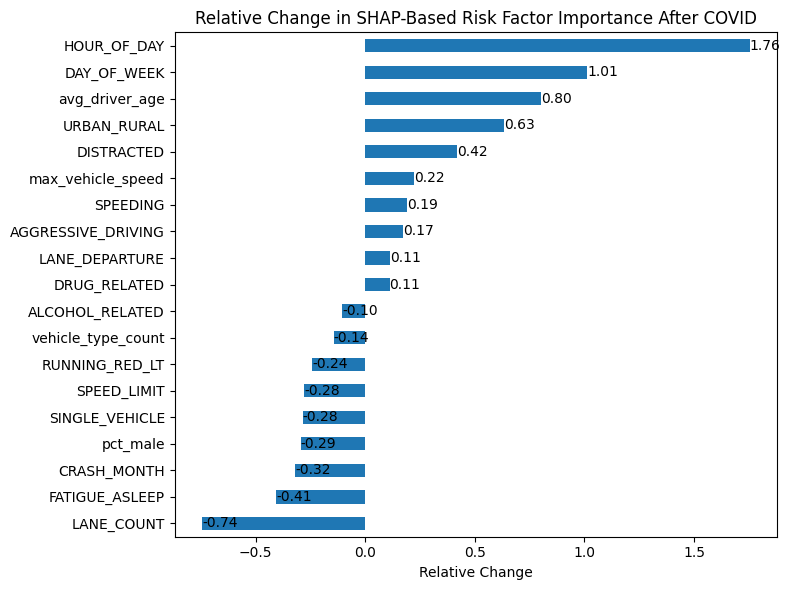

In [ ]:
# ======================================================
# Step 29: Visualize SHAP change
# ======================================================
fig, ax = plt.subplots(figsize=(8,6))

# Plot
shap_comparison["Relative_Change"].sort_values().plot.barh(ax=ax)

# Title and labels
ax.set_title("Relative Change in SHAP-Based Risk Factor Importance After COVID")
ax.set_xlabel("Relative Change")

# Add data labels
for i, v in enumerate(shap_comparison["Relative_Change"].sort_values()):
    ax.text(v, i, f"{v:.2f}", va='center')

plt.tight_layout()
plt.show()

## Step 30 — SHAP dependence plots for key variables

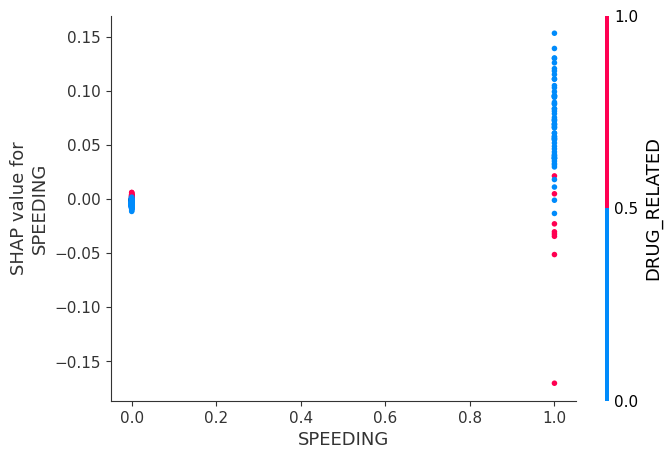

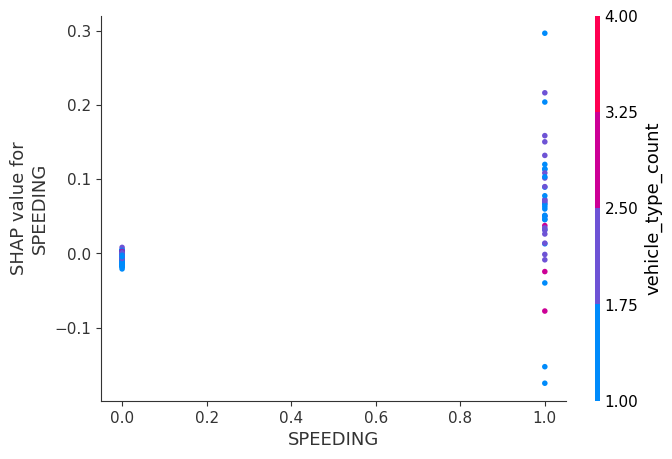

In [37]:
# Example dependence plot for Pre-COVID
shap.dependence_plot(
    "SPEEDING",
    shap_values_pre,
    X_pre_sample
)

# Example dependence plot for Post-COVID
shap.dependence_plot(
    "SPEEDING",
    shap_values_post,
    X_post_sample
)